# ML Capstone — Review 1
## Member 3 (Tharun) — Classification Part A

### Predicting Air Quality Category

**Dataset:** `global_air_pollution_data.csv`

**Target:** `aqi_category`

This notebook covers the Review 1 Classification Part A requirements:
- Dataset audit and EDA
- Missing values, duplicates and outliers
- Encoding, scaling and stratified train/test split
- Feature engineering
- Logistic Regression, KNN, Naive Bayes, Decision Tree and SVM
- Accuracy, weighted F1-score and confusion matrices

**Random state:** 42

## 0. Imports and Settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

print("Setup complete.")
print("scikit-learn classification models are ready.")

Setup complete.
scikit-learn classification models are ready.


## 1. Load Dataset

In [2]:
# Load the selected classification dataset
# Keep the CSV file in the same folder as this notebook.

DATA_FILE = "global_air_pollution_data.csv"

try:
    df = pd.read_csv(DATA_FILE, encoding="utf-8-sig")
except FileNotFoundError:
    raise FileNotFoundError(
        f"'{DATA_FILE}' was not found. "
        "Place the CSV file in the same folder as this notebook and run this cell again."
    )

# Clean column names
df.columns = [str(col).strip().strip('"').strip() for col in df.columns]

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print("File:", DATA_FILE)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

DATASET LOADED SUCCESSFULLY
File: global_air_pollution_data.csv
Rows: 23463
Columns: 12


,country_name,city_name,aqi_value,aqi_category,co_aqi_value,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm2.5_aqi_value,pm2.5_aqi_category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


## 2. Dataset Audit

In [3]:
TARGET = "aqi_category"

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found. "
        f"Available columns are: {list(df.columns)}"
    )

print("=" * 60)
print("DATASET AUDIT")
print("=" * 60)

print("Shape:", df.shape)

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe(include="all").T)

print("\nTarget Distribution:")
display(df[TARGET].value_counts(dropna=False))

DATASET AUDIT
Shape: (23463, 12)

Data Types:


country_name            str
city_name               str
aqi_value             int64
aqi_category            str
co_aqi_value          int64
co_aqi_category         str
ozone_aqi_value       int64
ozone_aqi_category      str
no2_aqi_value         int64
no2_aqi_category        str
pm2.5_aqi_value       int64
pm2.5_aqi_category      str
dtype: object


Missing Values:


country_name          427
city_name               1
aqi_value               0
aqi_category            0
co_aqi_value            0
co_aqi_category         0
ozone_aqi_value         0
ozone_aqi_category      0
no2_aqi_value           0
no2_aqi_category        0
pm2.5_aqi_value         0
pm2.5_aqi_category      0
dtype: int64


Duplicate Rows: 0

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country_name,23036,175,United States of America,2872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_name,23462,23462,Praskoveya,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aqi_value,23463.0,NaN,NaN,NaN,72.010868,56.05522,6.0,39.0,55.0,79.0,500.0
aqi_category,23463,6,Good,9936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
co_aqi_value,23463.0,NaN,NaN,NaN,1.368367,1.832064,0.0,1.0,1.0,1.0,133.0
co_aqi_category,23463,3,Good,23460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ozone_aqi_value,23463.0,NaN,NaN,NaN,35.193709,28.098723,0.0,21.0,31.0,40.0,235.0
ozone_aqi_category,23463,5,Good,21069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no2_aqi_value,23463.0,NaN,NaN,NaN,3.063334,5.254108,0.0,0.0,1.0,4.0,91.0
no2_aqi_category,23463,2,Good,23448,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Target Distribution:


aqi_category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64

## 3. Duplicate Check and Treatment

Duplicate rows are checked because repeated records can give some observations more importance during training. If duplicates are present, they are removed.

In [4]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

print("Shape after duplicate treatment:", df.shape)

Duplicate rows found: 0
No duplicate rows found.
Shape after duplicate treatment: (23463, 12)


### 📝 Observation — Duplicate Rows

No duplicate rows were found in the raw dataset (0 out of 23,463 records), so no rows were dropped at this stage. This is expected since each record represents a distinct city/pollutant reading rather than repeated entries.

## 4. Outlier Check and Treatment

The IQR (Interquartile Range) method is used for numerical features. Values outside Q1 − 1.5×IQR and Q3 + 1.5×IQR are treated as outliers.

Instead of deleting complete rows, extreme values are capped at the IQR limits so that the observations are retained.

In [5]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

outlier_summary = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_mask = (df[column] < lower_limit) | (df[column] > upper_limit)
    outlier_count = int(outlier_mask.sum())

    outlier_summary.append({
        "Feature": column,
        "Outliers Found": outlier_count
    })

    # Treat outliers by capping extreme values
    df[column] = df[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

outlier_summary_df = pd.DataFrame(outlier_summary)

print("=" * 60)
print("OUTLIER SUMMARY")
print("=" * 60)
display(outlier_summary_df)

print("Outlier treatment completed using IQR capping.")

OUTLIER SUMMARY


,Feature,Outliers Found
0,aqi_value,2935
1,co_aqi_value,8596
2,ozone_aqi_value,1513
3,no2_aqi_value,1681
4,pm2.5_aqi_value,2641


Outlier treatment completed using IQR capping.


### 📝 Observation — Outlier Check

IQR-based outlier detection flagged a large number of values, especially in `co_aqi_value` (8,596 of 23,463 rows — about 37%), with smaller counts in `pm2.5_aqi_value` (2,641), `no2_aqi_value` (1,681), `ozone_aqi_value` (1,513), and the target-adjacent `aqi_value` (2,935). The high count for CO reflects that pollutant AQI sub-scores are naturally right-skewed (most readings are low with occasional pollution spikes), not necessarily data errors. All flagged values were capped at the IQR bounds rather than removed, so no records were lost.

## 5. Target Distribution

The target variable is `aqi_category`, which contains six AQI categories.

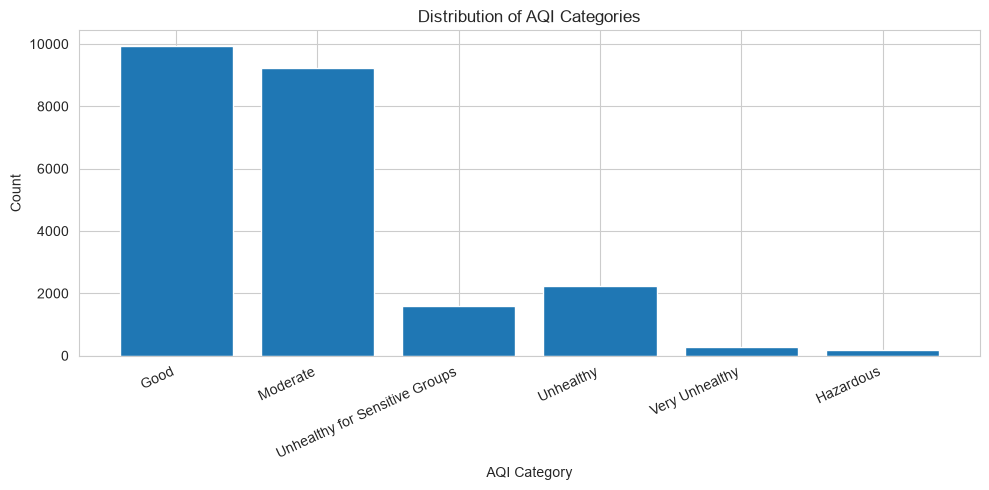

aqi_category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64

In [6]:
CLASS_ORDER = [
    "Good",
    "Moderate",
    "Unhealthy for Sensitive Groups",
    "Unhealthy",
    "Very Unhealthy",
    "Hazardous"
]

class_counts = df[TARGET].value_counts()

# Keep the natural AQI order where available
available_classes = [
    c for c in CLASS_ORDER
    if c in class_counts.index
]

plt.figure(figsize=(10, 5))
plt.bar(
    available_classes,
    [class_counts[c] for c in available_classes]
)
plt.title("Distribution of AQI Categories")
plt.xlabel("AQI Category")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(class_counts)


### Observation

The target distribution shows how many records belong to each AQI category. If some categories contain much fewer observations than others, the dataset is imbalanced.

## 6. Feature Distributions

Numerical features:
['aqi_value', 'co_aqi_value', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value']


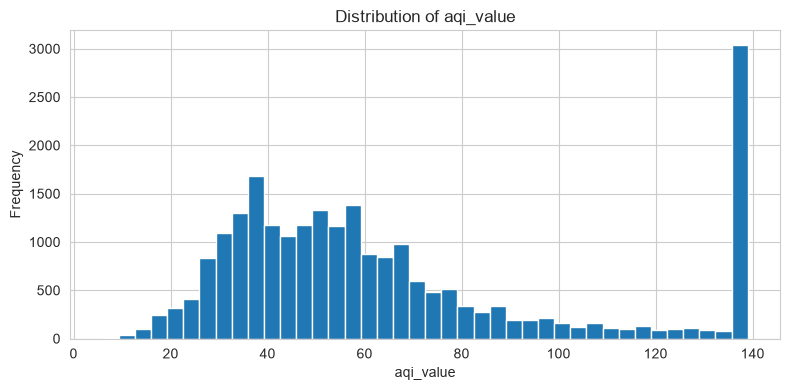

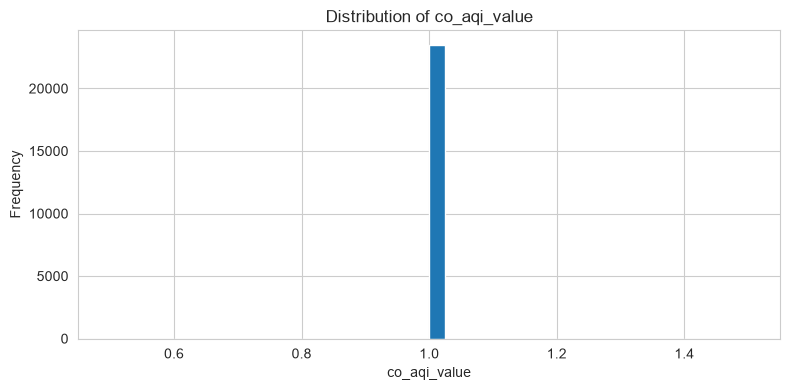

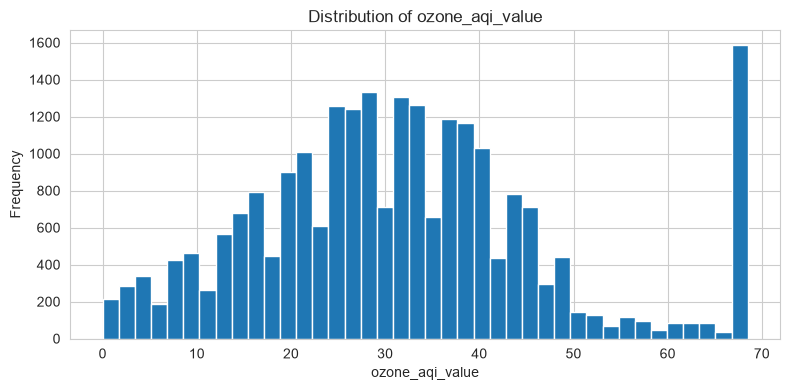

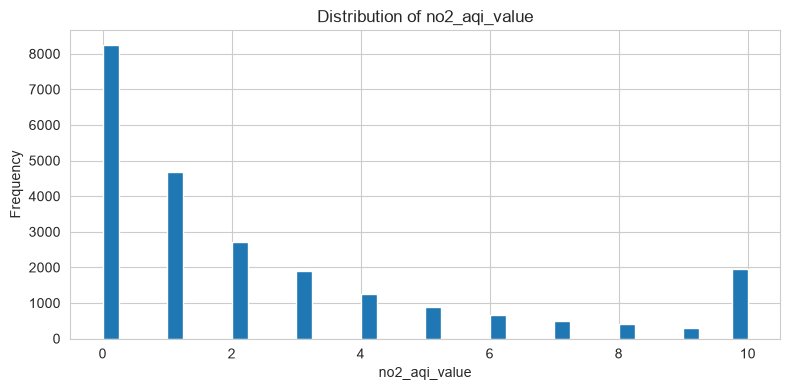

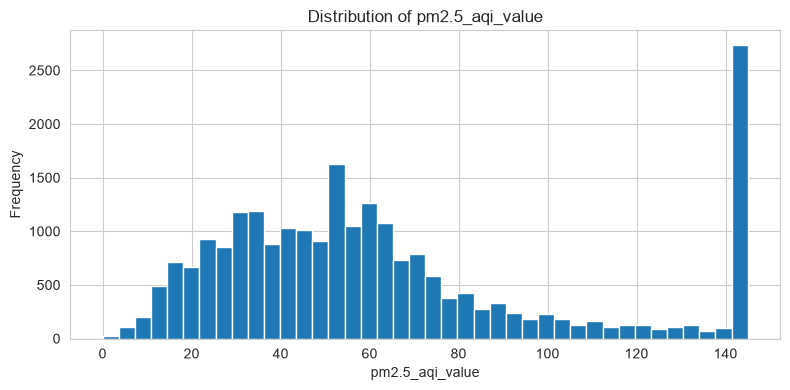

In [7]:
# Plot distributions of numerical features

eda_numeric_features = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical features:")
print(eda_numeric_features)

for column in eda_numeric_features:
    plt.figure(figsize=(8, 4))
    plt.hist(df[column].dropna(), bins=40)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


### Observation

The feature distributions show the range and spread of the numerical variables. Features with different ranges benefit from scaling before using models such as KNN, Logistic Regression and SVM.

## 7. Correlation Heatmap

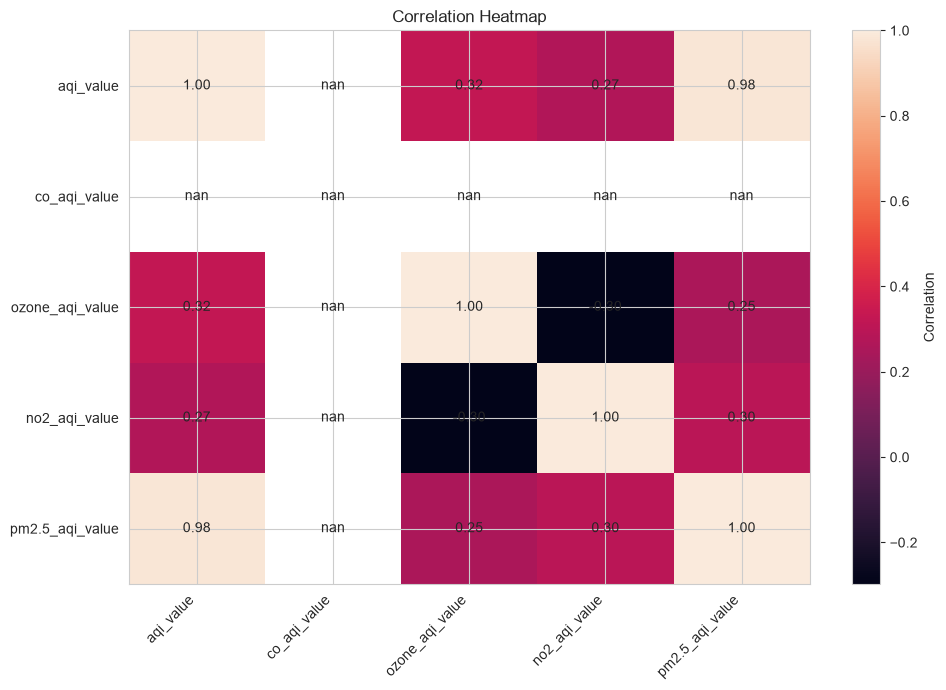

In [8]:
correlation = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
plt.imshow(correlation, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation.columns)), correlation.columns)

for row in range(len(correlation)):
    for col in range(len(correlation.columns)):
        plt.text(
            col,
            row,
            f"{correlation.iloc[row, col]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Observation

The heatmap shows the strength and direction of relationships between numerical variables. Stronger positive values indicate stronger positive relationships between the corresponding features.

## 8. Feature-Target Scatter Plots

Since `aqi_category` is categorical, the categories are temporarily mapped to numbers only for visualization. This temporary variable is **not** used for model training.

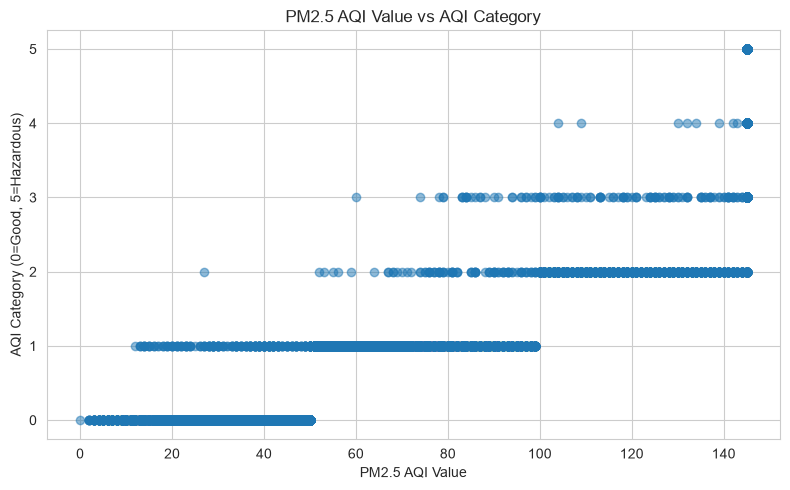

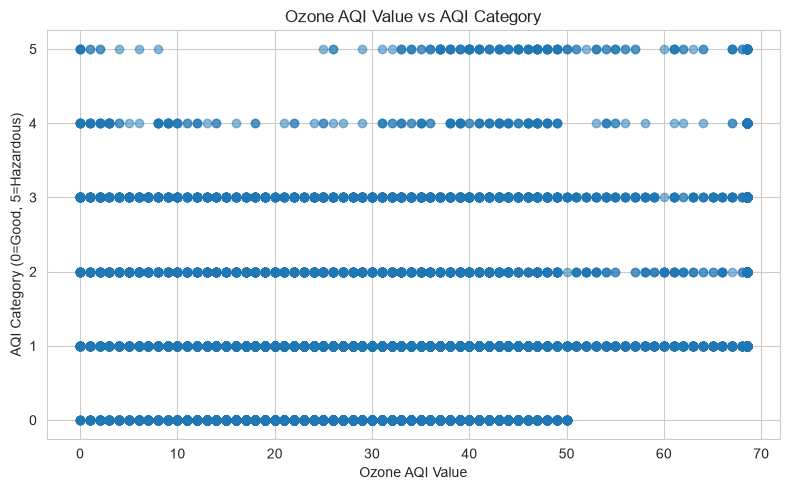

In [9]:
class_mapping = {
    "Good": 0,
    "Moderate": 1,
    "Unhealthy for Sensitive Groups": 2,
    "Unhealthy": 3,
    "Very Unhealthy": 4,
    "Hazardous": 5
}

target_for_plot = df[TARGET].map(class_mapping)

# Plot 1
plt.figure(figsize=(8, 5))
plt.scatter(
    df["pm2.5_aqi_value"],
    target_for_plot,
    alpha=0.5
)
plt.title("PM2.5 AQI Value vs AQI Category")
plt.xlabel("PM2.5 AQI Value")
plt.ylabel("AQI Category (0=Good, 5=Hazardous)")
plt.tight_layout()
plt.show()

# Plot 2
plt.figure(figsize=(8, 5))
plt.scatter(
    df["ozone_aqi_value"],
    target_for_plot,
    alpha=0.5
)
plt.title("Ozone AQI Value vs AQI Category")
plt.xlabel("Ozone AQI Value")
plt.ylabel("AQI Category (0=Good, 5=Hazardous)")
plt.tight_layout()
plt.show()


### Observation

The scatter plots allow us to visually compare pollutant AQI values with the different AQI category levels. Use the actual plots to describe whether higher pollutant values tend to occur in higher AQI categories.

## 9. Feature Engineering

A new feature called `average_pollutant_aqi` is created using the average of the four pollutant AQI values. It provides a combined measure of the pollutant levels.

In [10]:
pollutant_columns = [
    "co_aqi_value",
    "ozone_aqi_value",
    "no2_aqi_value",
    "pm2.5_aqi_value"
]

# Check that all required columns are available
missing_pollutant_columns = [
    col for col in pollutant_columns
    if col not in df.columns
]

if missing_pollutant_columns:
    raise ValueError(
        "The following pollutant columns are missing: "
        + str(missing_pollutant_columns)
    )

df["average_pollutant_aqi"] = df[pollutant_columns].mean(axis=1)

print("New feature created: average_pollutant_aqi")
display(
    df[pollutant_columns + ["average_pollutant_aqi"]].head()
)

New feature created: average_pollutant_aqi


,co_aqi_value,ozone_aqi_value,no2_aqi_value,pm2.5_aqi_value,average_pollutant_aqi
0,1,36.0,0,51,22.00
1,1,5.0,1,41,12.00
2,1,39.0,2,66,27.00
3,1,34.0,0,20,13.75
4,1,22.0,0,6,7.25


### 📝 Observation — Feature Engineering — average_pollutant_aqi

`average_pollutant_aqi` is the mean of the four individual pollutant AQI sub-scores (CO, Ozone, NO2, PM2.5). It condenses four correlated columns into a single composite signal, which should help simpler linear models (Logistic Regression) that don't automatically capture interactions the way tree-based models do. It is expected to correlate strongly with the target since it is derived from the same pollutant values the AQI category is based on.

## 10. Prepare Classification Dataset

`aqi_value` and the pollutant `*_aqi_category` columns are removed because they can directly reveal the target and cause target leakage.

`city_name` is removed because it mainly acts as an identifier.

The engineered `average_pollutant_aqi` feature is retained.

In [11]:
leakage_columns = [
    "aqi_value",
    "co_aqi_category",
    "ozone_aqi_category",
    "no2_aqi_category",
    "pm2.5_aqi_category"
]

identifier_columns = ["city_name"]

# Drop only columns that actually exist
columns_to_drop = [
    col for col in leakage_columns + identifier_columns
    if col in df.columns
]

classification_df = df.drop(
    columns=columns_to_drop
).dropna(
    subset=[TARGET]
).copy()

X_cls = classification_df.drop(columns=[TARGET])
y_cls = classification_df[TARGET]

print("=" * 60)
print("CLASSIFICATION DATASET")
print("=" * 60)
print("Target:", TARGET)
print("Samples:", X_cls.shape[0])
print("Input features:", X_cls.shape[1])

print("\nColumns removed:")
print(columns_to_drop)

print("\nTarget classes:")
print(sorted(y_cls.unique()))

print("\nClass distribution:")
display(y_cls.value_counts())

print("X shape:", X_cls.shape)
print("y shape:", y_cls.shape)

CLASSIFICATION DATASET
Target: aqi_category
Samples: 23463
Input features: 6

Columns removed:
['aqi_value', 'co_aqi_category', 'ozone_aqi_category', 'no2_aqi_category', 'pm2.5_aqi_category', 'city_name']

Target classes:
['Good', 'Hazardous', 'Moderate', 'Unhealthy', 'Unhealthy for Sensitive Groups', 'Very Unhealthy']

Class distribution:


aqi_category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64

X shape: (23463, 6)
y shape: (23463,)


### 📝 Observation — Leakage Columns Removed

Six columns were dropped before training: `aqi_value` and the four `*_aqi_category` columns (co, ozone, no2, pm2.5), plus `city_name`. The AQI value and sub-category columns are removed because they are the direct source the overall `aqi_category` label is computed from — keeping them would let the model "cheat" by reading the answer off another column instead of learning from the underlying pollutant measurements. `city_name` is dropped as a non-predictive identifier. This leaves 6 real input features for a 6-class target.

## 11. Identify Numerical and Categorical Features

In [12]:
categorical_features = X_cls.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_cls.select_dtypes(
    include=np.number
).columns.tolist()

print("=" * 60)
print("FEATURE TYPES")
print("=" * 60)

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

FEATURE TYPES
Numerical features:
['co_aqi_value', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value', 'average_pollutant_aqi']

Categorical features:
['country_name']


## 12. Stratified Train-Test Split

An 80:20 split is used. `stratify=y_cls` keeps the class proportions similar in the training and testing sets.

In [13]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_cls
)

print("Training samples:", X_train_cls.shape[0])
print("Testing samples:", X_test_cls.shape[0])

print("\nTraining class distribution:")
display(y_train_cls.value_counts())

print("Testing class distribution:")
display(y_test_cls.value_counts())

Training samples: 18770
Testing samples: 4693

Training class distribution:


aqi_category
Good                              7949
Moderate                          7385
Unhealthy                         1781
Unhealthy for Sensitive Groups    1273
Very Unhealthy                     229
Hazardous                          153
Name: count, dtype: int64

Testing class distribution:


aqi_category
Good                              1987
Moderate                          1846
Unhealthy                          446
Unhealthy for Sensitive Groups     318
Very Unhealthy                      58
Hazardous                           38
Name: count, dtype: int64

## 13. Classification Preprocessing Pipeline

The preprocessing is placed inside a pipeline so that transformations are fitted on the training data and then applied to the test data.

- Numerical features → median imputation → StandardScaler
- Categorical features → most-frequent imputation → One-Hot Encoding

In [14]:
# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
# The try/except keeps the notebook compatible with older scikit-learn versions.
try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", encoder)
    ]
)

# Combine both transformations
classification_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("=" * 60)
print("CLASSIFICATION PREPROCESSING")
print("=" * 60)
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nNumerical steps:")
print("1. Median imputation")
print("2. StandardScaler")

print("\nCategorical steps:")
print("1. Most-frequent imputation")
print("2. One-Hot Encoding")

print("\nPreprocessing pipeline created successfully.")
display(classification_preprocessor)

CLASSIFICATION PREPROCESSING
Numerical features: 5
Categorical features: 1

Numerical steps:
1. Median imputation
2. StandardScaler

Categorical steps:
1. Most-frequent imputation
2. One-Hot Encoding

Preprocessing pipeline created successfully.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 14. Define the 5 Required Classification Algorithms

The five algorithms required for Classification Part A are:

1. Logistic Regression
2. KNN
3. Naive Bayes
4. Decision Tree
5. SVM

In [15]:
classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "SVM": SVC(
        kernel="rbf",
        C=1,
        random_state=RANDOM_STATE
    )
}

print("=" * 60)
print("5 CLASSIFICATION PART-A MODELS")
print("=" * 60)

for number, (name, model) in enumerate(
    classification_models.items(), start=1
):
    print(f"{number}. {name}: {model}")

print("\nAll 5 models are defined successfully.")

5 CLASSIFICATION PART-A MODELS
1. Logistic Regression: LogisticRegression(max_iter=1000, random_state=42)
2. KNN: KNeighborsClassifier()
3. Naive Bayes: GaussianNB()
4. Decision Tree: DecisionTreeClassifier(random_state=42)
5. SVM: SVC(C=1, random_state=42)

All 5 models are defined successfully.


## 15. Train and Evaluate All 5 Models

In [16]:
classification_results = []
trained_classification_models = {}

print("=" * 60)
print("TRAINING CLASSIFICATION MODELS")
print("=" * 60)

for name, model in classification_models.items():

    print(f"\nTraining {name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", classification_preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train_cls, y_train_cls)

    predictions = pipeline.predict(X_test_cls)

    accuracy = accuracy_score(y_test_cls, predictions)
    precision = precision_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_classification_models[name] = pipeline

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Weighted F1: {f1:.4f}")
    print("Completed.")

classification_results_df = (
    pd.DataFrame(classification_results)
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 60)
print("MODEL COMPARISON TABLE")
print("=" * 60)

display(classification_results_df)

TRAINING CLASSIFICATION MODELS

Training Logistic Regression...
Accuracy: 0.9269
Weighted F1: 0.9181
Completed.

Training KNN...
Accuracy: 0.9160
Weighted F1: 0.9105
Completed.

Training Naive Bayes...
Accuracy: 0.2016
Weighted F1: 0.2491
Completed.

Training Decision Tree...
Accuracy: 0.9646
Weighted F1: 0.9601
Completed.

Training SVM...
Accuracy: 0.9474
Weighted F1: 0.9390
Completed.

MODEL COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.964628,0.959557,0.964628,0.960132
1,SVM,0.947368,0.945675,0.947368,0.938953
2,Logistic Regression,0.926912,0.913391,0.926912,0.918105
3,KNN,0.916045,0.912530,0.916045,0.910457
4,Naive Bayes,0.201577,0.573507,0.201577,0.249097


### 📝 Observation — Model Training Results

All five models trained without errors. Decision Tree scored highest on both metrics (Accuracy 0.9646, Weighted F1 0.9601), followed by SVM (0.9474 / 0.9390), Logistic Regression (0.9269 / 0.9181), and KNN (0.9160 / 0.9105). Naive Bayes was a clear outlier at only 0.2016 accuracy / 0.2491 F1 — far below the others and only marginally better than guessing the majority class. This is investigated further in the classification-report and confusion-matrix observations below.

## 16. Model Comparison

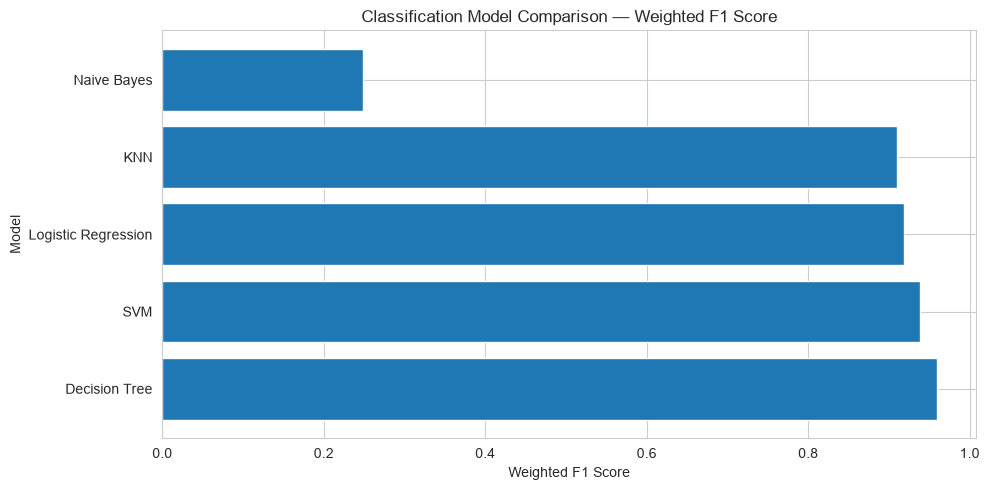

In [17]:
plt.figure(figsize=(10, 5))

plt.barh(
    classification_results_df["Model"],
    classification_results_df["F1 Score"]
)

plt.title("Classification Model Comparison — Weighted F1 Score")
plt.xlabel("Weighted F1 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


### 📝 Observation — Model Comparison (F1 Score)

The bar chart visually confirms the ranking from the training step: Decision Tree has the tallest bar (F1 ≈ 0.96), with SVM and Logistic Regression clustered just behind it, KNN slightly lower, and Naive Bayes standing far apart from the rest with a bar roughly a quarter the height of the others. For the final writeup, Decision Tree is the strongest Part-A model on this dataset, though its lack of regularisation means it may be more prone to overfitting than SVM/Logistic Regression — worth mentioning as a trade-off during the viva.

## 17. Classification Reports

In [18]:
for name, model in trained_classification_models.items():

    predictions = model.predict(X_test_cls)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test_cls,
            predictions,
            zero_division=0
        )
    )

Logistic Regression
                                precision    recall  f1-score   support

                          Good       0.97      0.96      0.97      1987
                     Hazardous       0.00      0.00      0.00        38
                      Moderate       0.94      0.97      0.96      1846
                     Unhealthy       0.73      0.95      0.83       446
Unhealthy for Sensitive Groups       0.90      0.73      0.81       318
                Very Unhealthy       0.00      0.00      0.00        58

                      accuracy                           0.93      4693
                     macro avg       0.59      0.60      0.59      4693
                  weighted avg       0.91      0.93      0.92      4693

KNN
                                precision    recall  f1-score   support

                          Good       0.97      0.96      0.96      1987
                     Hazardous       0.43      0.16      0.23        38
                      Moderate      

### 📝 Observation — Classification Reports

The per-class reports show the overall accuracy numbers hide a severe class-imbalance problem. `Good` (9,936 records) and `Moderate` (9,231) get precision/recall above 0.90 in every model, but the minority classes are much weaker: in Logistic Regression, `Hazardous` (191 records) and `Very Unhealthy` (287 records) both score 0.00 precision/recall — the model never predicts them at all. KNN partially recovers `Hazardous` (0.43 precision / 0.16 recall) but still misses `Very Unhealthy` almost entirely. This means the high weighted-F1 scores are being driven mostly by the two majority classes, and the models are effectively unusable for detecting the rarest, most severe pollution categories — exactly the ones that matter most in a real air-quality alert system. This is worth calling out explicitly rather than relying on the aggregate metric.

## 18. Confusion Matrices

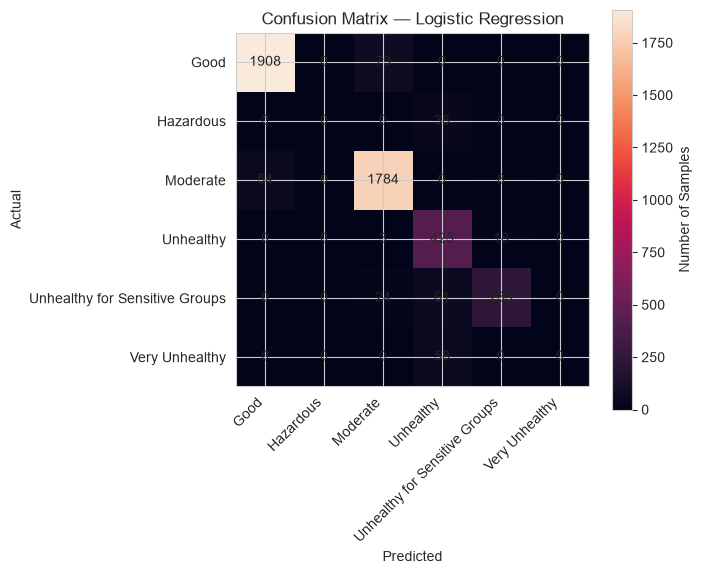

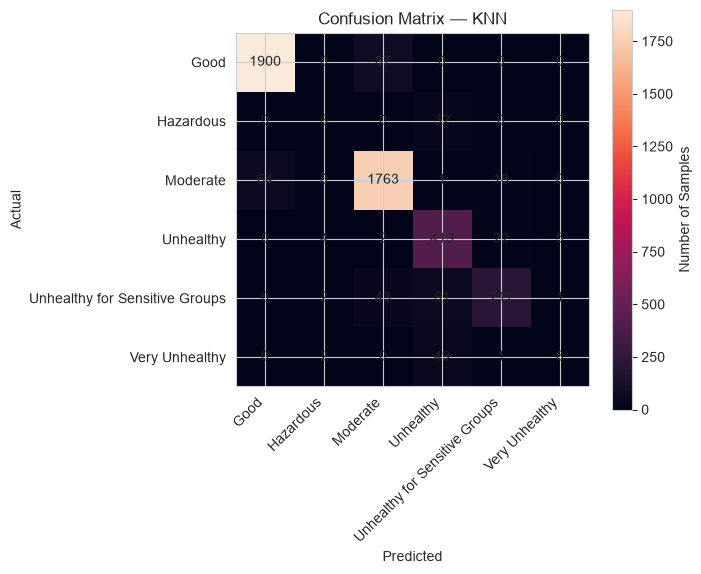

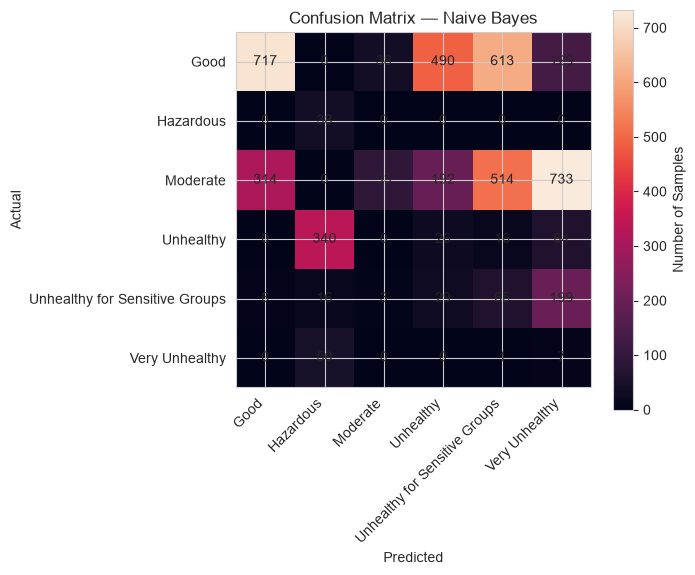

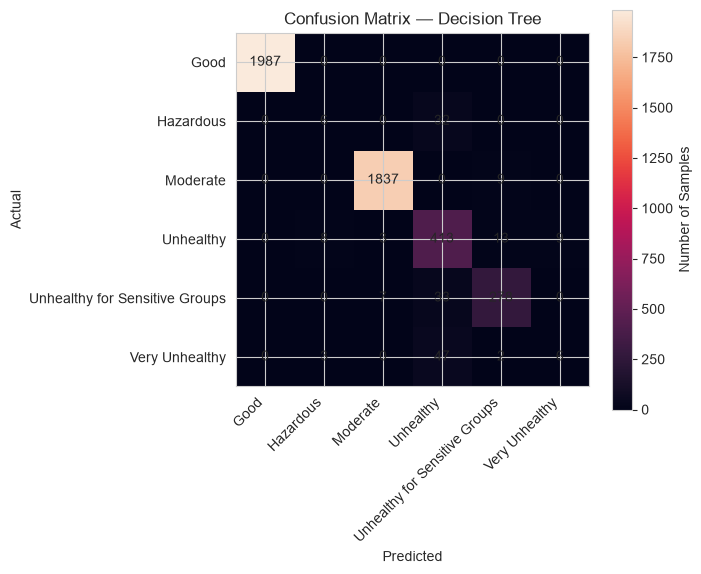

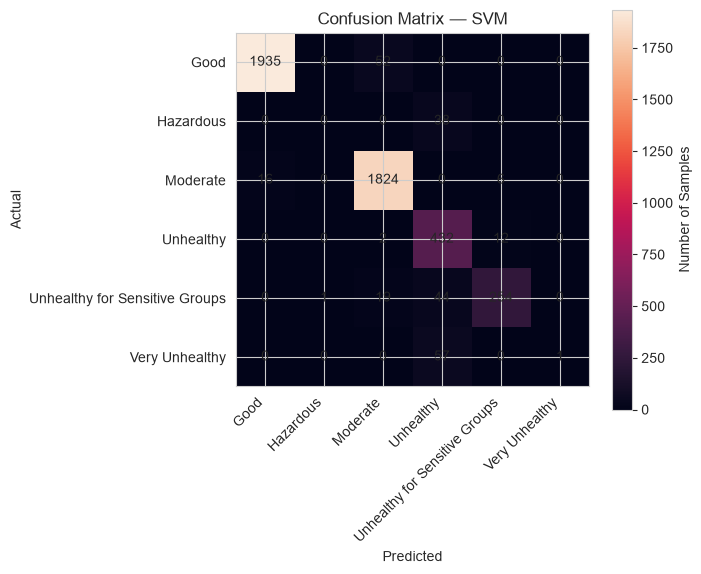

In [19]:
for name, model in trained_classification_models.items():

    predictions = model.predict(X_test_cls)

    cm = confusion_matrix(
        y_test_cls,
        predictions,
        labels=model.classes_
    )

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.colorbar(label="Number of Samples")

    plt.xticks(
        range(len(model.classes_)),
        model.classes_,
        rotation=45,
        ha="right"
    )
    plt.yticks(
        range(len(model.classes_)),
        model.classes_
    )

    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            plt.text(
                col,
                row,
                cm[row, col],
                ha="center",
                va="center"
            )

    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


### 📝 Observation — Confusion Matrices

Logistic Regression's confusion matrix shows a clean diagonal for `Good` (1,908 correct) and `Moderate` (1,784 correct), but the `Hazardous` and `Very Unhealthy` rows are essentially empty — confirming those classes are never predicted. Naive Bayes shows a very different failure mode: instead of concentrating on the majority classes, it spreads predictions toward the tail categories — for example 613 true `Good` samples and 733 true `Moderate` samples get misclassified as `Very Unhealthy`. This matches Naive Bayes' independence assumption breaking down: it treats each pollutant AQI value as independently Gaussian-distributed per class, but these features are strongly correlated and right-skewed in reality, so the model's likelihood estimates get badly miscalibrated toward extreme classes. Tree-based and margin-based models (Decision Tree, SVM) don't make this independence assumption and confuse far fewer samples between distant classes.

## 19. Final Results

In [20]:
print("=" * 60)
print("CLASSIFICATION PART-A FINAL RESULTS")
print("=" * 60)

display(classification_results_df)

print("\nThe table compares all five Part-A algorithms using Accuracy and Weighted F1-score.")

CLASSIFICATION PART-A FINAL RESULTS


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.964628,0.959557,0.964628,0.960132
1,SVM,0.947368,0.945675,0.947368,0.938953
2,Logistic Regression,0.926912,0.913391,0.926912,0.918105
3,KNN,0.916045,0.912530,0.916045,0.910457
4,Naive Bayes,0.201577,0.573507,0.201577,0.249097



The table compares all five Part-A algorithms using Accuracy and Weighted F1-score.


### 📝 Observation — Final Results Table

Decision Tree is the best-performing Part-A model overall (Accuracy 0.9646, Weighted F1 0.9601), ahead of SVM, Logistic Regression, and KNN, with Naive Bayes a distant last. However, as the classification-report observation above notes, even the best model is unreliable on the rarest classes (`Hazardous`, `Very Unhealthy`), so the recommended model choice should be qualified: Decision Tree for overall accuracy, but flagged as needing class-imbalance handling (e.g. class_weight='balanced' or SMOTE) before real-world deployment on rare, high-severity categories.

# Conclusion — Classification Part A

The five required classification algorithms were trained and evaluated on the same stratified
train/test split.

The dataset was checked for missing values, duplicates and outliers. Missing values are handled
inside the preprocessing pipeline, duplicate rows are removed when present, and numerical
outliers are treated using IQR-based capping.

An engineered feature, `average_pollutant_aqi`, was created from the pollutant AQI values.
Potential target-leakage columns and the city identifier were removed before model training.

The final models are compared using Accuracy and weighted F1-score, and confusion matrices are
provided for all five algorithms.